# LAB 1 for CS4243: Textures and Materials
## Notebook 1 — Inspecting the handcrafted components
> **Introduction.** This notebook is part of **LAB 1 for CS4243: Textures and Materials**. It develops visual intuition for Gabor filters, interpolated non-maximum suppression, hysteresis, and the aligned local descriptor using real MVTec texture images from the course data bundle.

## Learning goals
Connect each operation to a visible intermediate result, verify that all feature maps stay aligned, and identify channels that respond to orientation, colour, or boundaries.

## 1. Imports and reproducible configuration
This cell loads the branch APIs and fixes a compact bank configuration. Dataclass configuration makes every later figure reproducible.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np
import matplotlib.pyplot as plt
from texturelab.config import FeatureConfig, GaborConfig
from texturelab.data import read_manifest
from texturelab.supplied import load_image, rgb2gray, nms_nearest
from texturelab.gabor_branch import make_gabor_bank, gabor_energy_maps
from texturelab.edge_branch import detect_edges
from texturelab.features import extract_local_features

config = FeatureConfig(
    gabor=GaborConfig(
        frequencies=(0.08, 0.16, 0.28),
        phases=(0.0,),  # Radian offsets applied to the sine carrier.
        kernel_size=15,
        pool_size=9,
    )
)
mvtec = read_manifest(ROOT / "manifests" / "mvtec_textures.csv")

## 2. Visualise the five MVTec material families
One normal training image per class exposes real differences in frequency, regularity, colour, and edge structure. Images are resized only to keep the instructional notebook responsive.

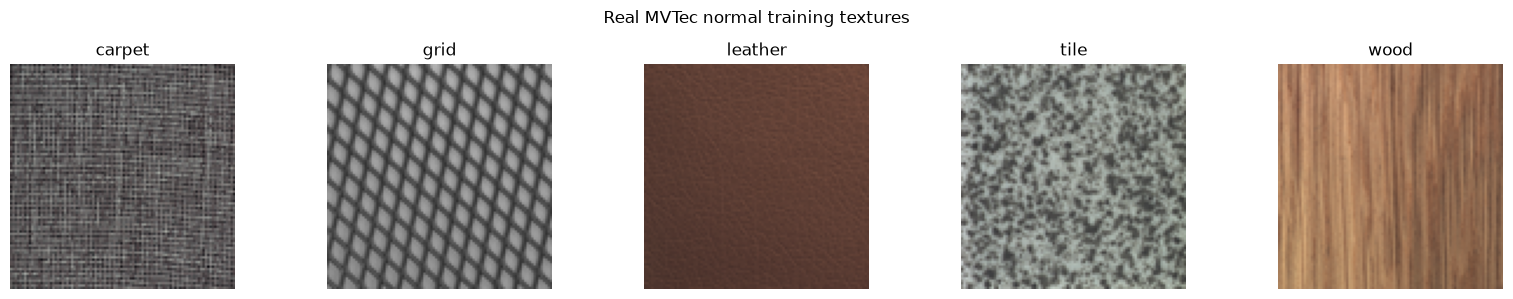

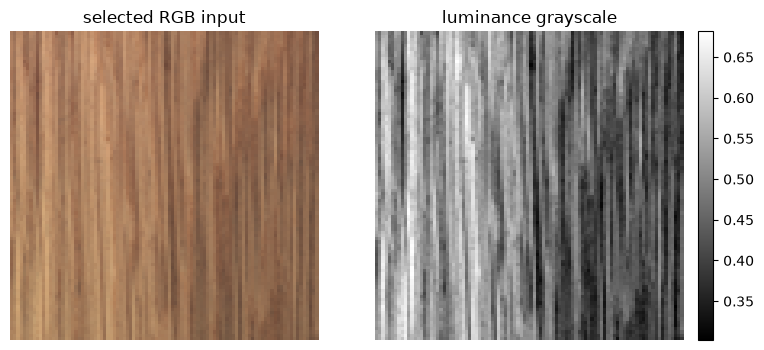

RGB range: (0.2235294133424759, 0.8392156958580017)
gray range: (0.3022839426994324, 0.6816494464874268) shape: (96, 96)


In [2]:
materials = ["carpet", "grid", "leather", "tile", "wood"]
examples = {}
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for ax, material in zip(axes, materials):
    record = next(r for r in mvtec if r.split == "train" and r.material == material)
    sample = load_image(record.path, (96, 96))
    examples[material] = sample
    ax.imshow(sample)
    ax.set_title(material)
    ax.axis("off")
fig.suptitle("Real MVTec normal training textures")
fig.tight_layout()
image = examples["wood"]
gray = rgb2gray(image)

# Show the selected RGB input beside its luminance conversion.  The colorbar
# records the actual normalized intensity range used for display.
gray_min, gray_max = float(gray.min()), float(gray.max())
fig, axes = plt.subplots(1, 2, figsize=(8, 3.6))
axes[0].imshow(image)
axes[0].set_title("selected RGB input")
gray_artist = axes[1].imshow(gray, cmap="gray", vmin=gray_min, vmax=gray_max)
axes[1].set_title("luminance grayscale")
for ax in axes:
    ax.axis("off")
fig.colorbar(gray_artist, ax=axes[1], fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

print("RGB range:", (float(image.min()), float(image.max())))
print("gray range:", (float(gray.min()), float(gray.max())), "shape:", gray.shape)

## 3. Build and inspect the Gabor bank
Each frequency–orientation pair uses a **sine carrier** at every numeric phase offset listed in `GaborConfig.phases`. This notebook explicitly requests only $\phi=0$; add offsets such as `np.pi / 2` to that tuple to compare other sine phases. The number of kernels and all plot layouts below are derived from the configuration rather than assumed. Every kernel should be approximately zero mean and unit norm.

kernels: 12 maximum |mean|: 1.0596381549987655e-09


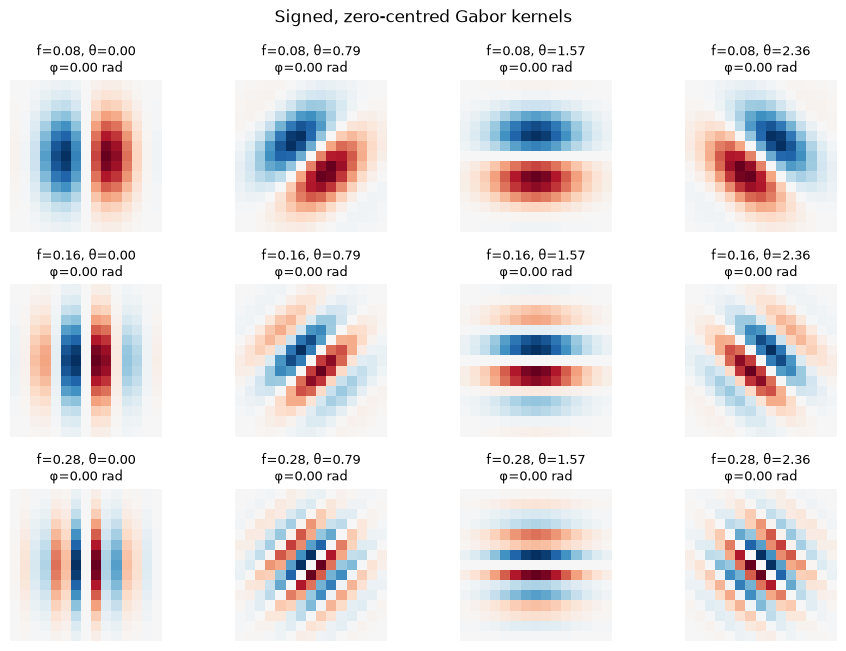

In [3]:
bank = make_gabor_bank(config.gabor)
print(
    "kernels:", len(bank), "maximum |mean|:", max(abs(float(k.mean())) for k, _ in bank)
)

# Gabor kernels are signed.  Use a zero-centred diverging scale independently
# for each kernel so positive and negative lobes have equal visual weight.
columns = len(config.gabor.orientations) * len(config.gabor.phases)
rows = len(config.gabor.frequencies)
fig, axes = plt.subplots(rows, columns, figsize=(2.3 * columns, 2.2 * rows))
for ax, (kernel, meta) in zip(np.asarray(axes).ravel(), bank):
    limit = max(float(np.abs(kernel).max()), np.finfo(np.float32).eps)
    ax.imshow(kernel, cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set_title(
        f"f={meta['frequency']:.2f}, θ={meta['orientation']:.2f}\nφ={meta['phase']:.2f} rad",
        fontsize=9,
    )
    ax.axis("off")
for ax in np.asarray(axes).ravel()[len(bank):]:
    ax.axis("off")
fig.suptitle("Signed, zero-centred Gabor kernels")
fig.tight_layout()
plt.show()

## 4. Local response-energy maps
Bright regions indicate a strong locally pooled response to a configured frequency, orientation, and sine-phase offset. Every configured kernel is shown below on one shared robust scale.

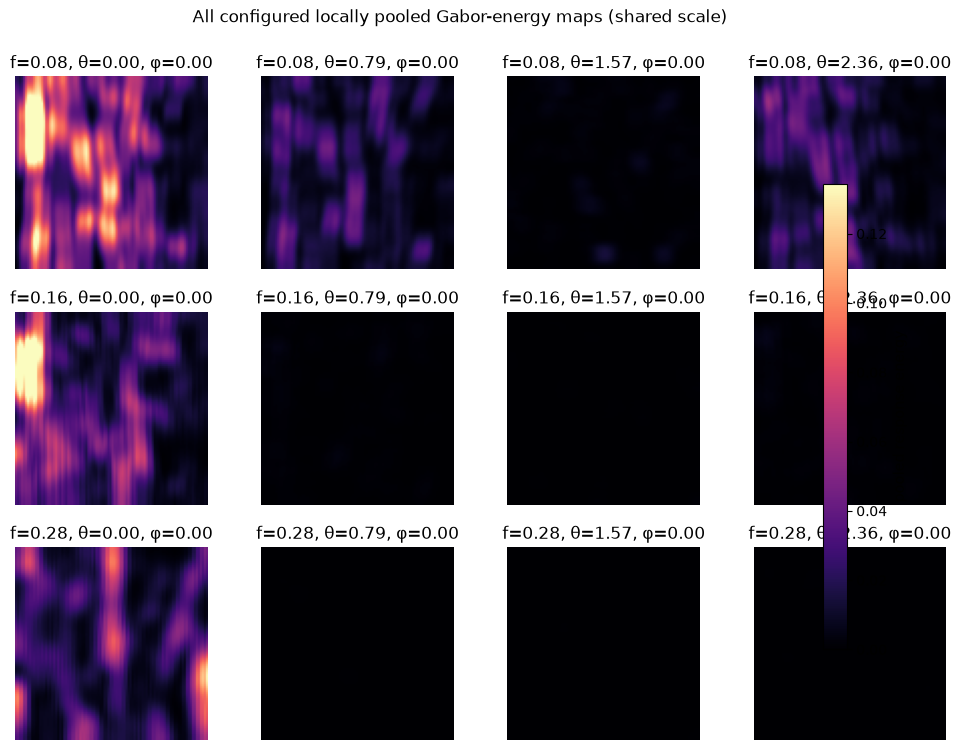

In [4]:
energy = gabor_energy_maps(gray, bank, config.gabor.pool_size)
energy_limit = max(float(np.percentile(energy, 99.5)), np.finfo(np.float32).eps)
columns = len(config.gabor.orientations) * len(config.gabor.phases)
rows = len(config.gabor.frequencies)
fig, axes = plt.subplots(rows, columns, figsize=(3.2 * columns, 2.8 * rows), squeeze=False)
for i, ax in enumerate(axes.flat):
    meta = bank[i][1]
    artist = ax.imshow(energy[..., i], cmap="magma", vmin=0.0, vmax=energy_limit)
    ax.set_title(
        f"f={meta['frequency']:.2f}, θ={meta['orientation']:.2f}, φ={meta['phase']:.2f}"
    )
    ax.axis("off")
fig.suptitle("All configured locally pooled Gabor-energy maps (shared scale)")
fig.colorbar(artist, ax=axes, shrink=0.72, label="pooled response energy")
fig.subplots_adjust(top=0.90, right=0.88, wspace=0.08, hspace=0.22)
plt.show()

assert energy.shape == gray.shape + (len(bank),)
assert np.isfinite(energy).all() and np.all(energy >= 0)

### Summarise orientation selectivity
Pooling each map over the image reveals which filters dominate this wood-like pattern.

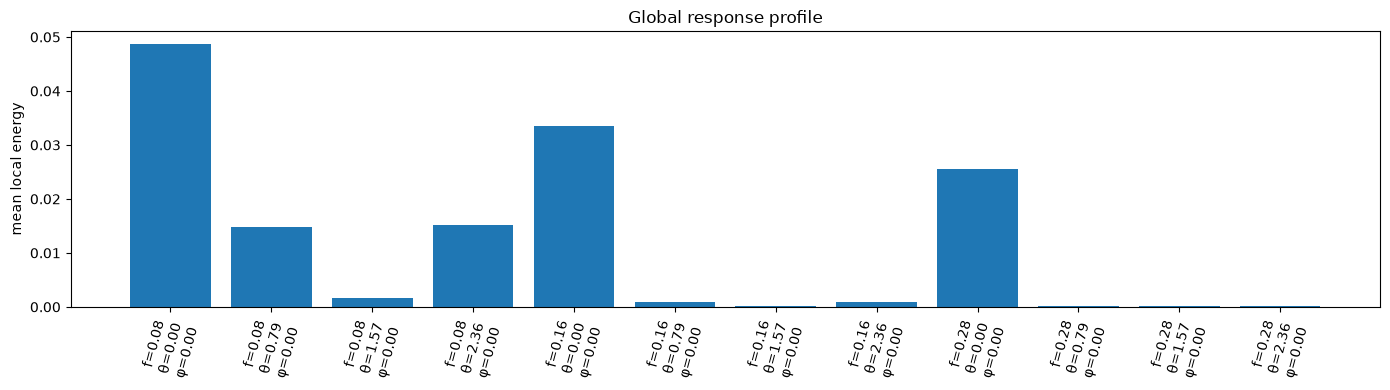

In [5]:
means = energy.mean((0, 1))
labels = [
    f"f={m['frequency']:.2f}\nθ={m['orientation']:.2f}\nφ={m['phase']:.2f}"
    for _, m in bank
]
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(np.arange(len(means)), means)
ax.set_xticks(np.arange(len(means)), labels, rotation=75)
ax.set_ylabel("mean local energy")
ax.set_title("Global response profile")
fig.tight_layout()

## 5. Follow the edge detector stage by stage
Compare smoothing/Sobel output, the supplied nearest-direction baseline, exact interpolated NMS, and final hysteresis-connected edges.

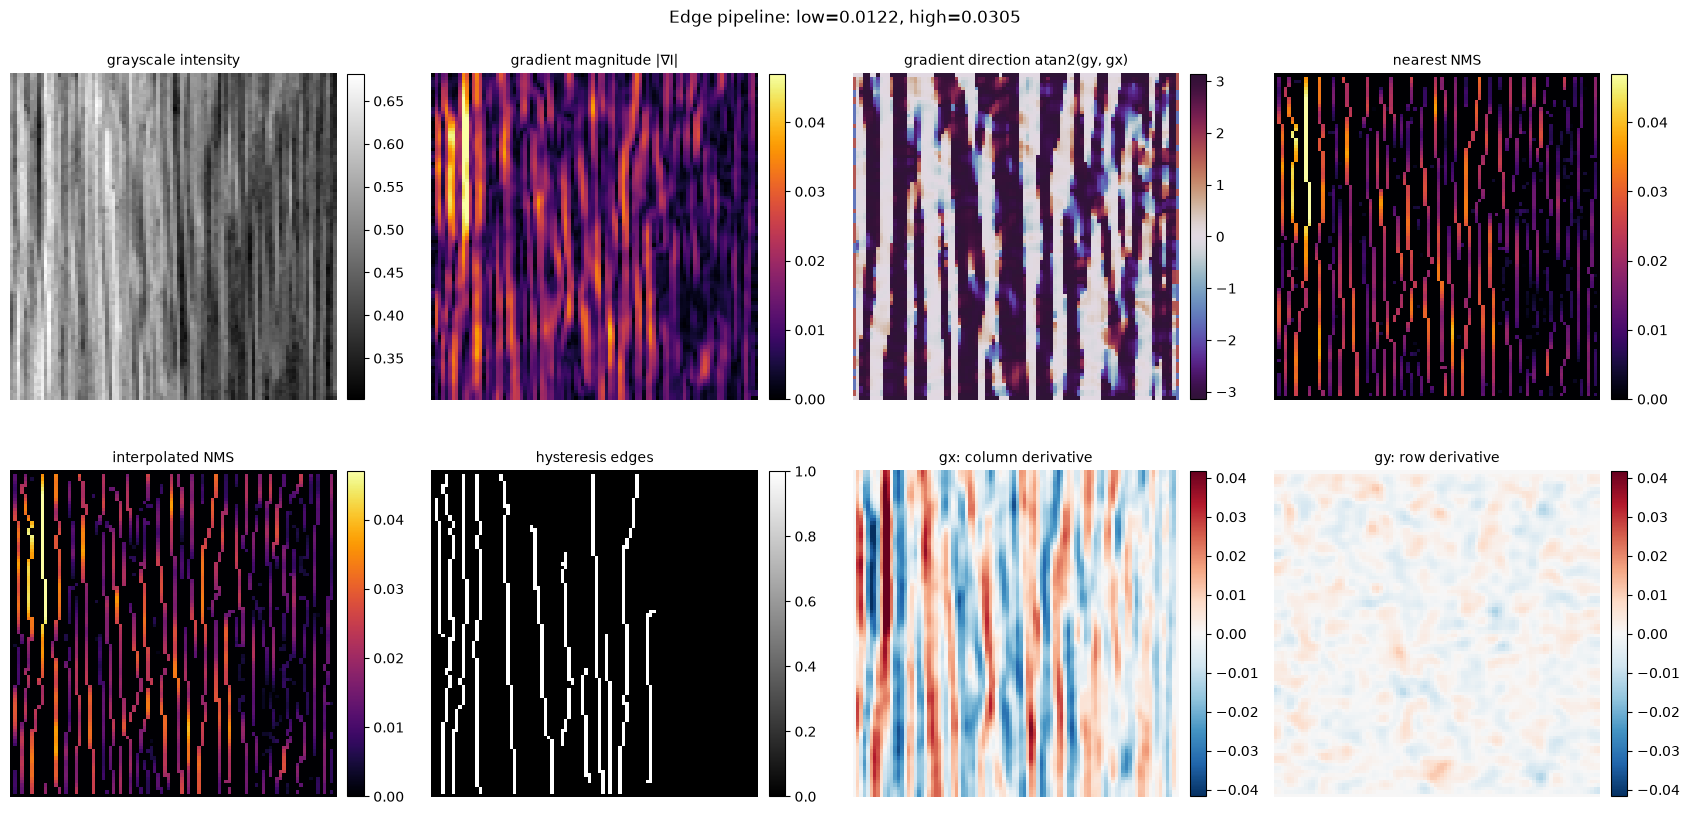

In [6]:
edge = detect_edges(gray, config.edge)
nearest = nms_nearest(edge["magnitude"], edge["direction"])

# Check the semantics before plotting: gx is the column derivative, gy the
# row derivative, magnitude is hypot(gx, gy), and direction is atan2(gy, gx).
assert all(np.asarray(edge[key]).shape == gray.shape for key in
           ("gx", "gy", "magnitude", "direction", "nms", "edges"))
assert np.allclose(edge["magnitude"], np.hypot(edge["gx"], edge["gy"]), atol=1e-6)
assert np.allclose(
    np.exp(1j * edge["direction"]),
    np.exp(1j * np.arctan2(edge["gy"], edge["gx"])),
    atol=1e-6,
)
assert edge["edges"].dtype == np.bool_

magnitude_limit = max(float(np.percentile(edge["magnitude"], 99.5)), np.finfo(np.float32).eps)
signed_limit = max(
    float(np.percentile(np.abs(np.concatenate([edge["gx"].ravel(), edge["gy"].ravel()])), 99.5)),
    np.finfo(np.float32).eps,
)
fig, axes = plt.subplots(2, 4, figsize=(17, 8.5))
panels = [
    ("grayscale intensity", gray, "gray", gray_min, gray_max),
    ("gradient magnitude |∇I|", edge["magnitude"], "inferno", 0.0, magnitude_limit),
    ("gradient direction atan2(gy, gx)", edge["direction"], "twilight_shifted", -np.pi, np.pi),
    ("nearest NMS", nearest, "inferno", 0.0, magnitude_limit),
    ("interpolated NMS", edge["nms"], "inferno", 0.0, magnitude_limit),
    ("hysteresis edges", edge["edges"], "gray", 0.0, 1.0),
    ("gx: column derivative", edge["gx"], "RdBu_r", -signed_limit, signed_limit),
    ("gy: row derivative", edge["gy"], "RdBu_r", -signed_limit, signed_limit),
]
for ax, (title, data, cmap, vmin, vmax) in zip(axes.flat, panels):
    artist = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
    fig.colorbar(artist, ax=ax, fraction=0.046, pad=0.03)
fig.suptitle(f"Edge pipeline: low={edge['low']:.4f}, high={edge['high']:.4f}")
fig.tight_layout()
plt.show()

### Where does interpolated NMS differ?
A signed difference image makes subtle thinning differences visible; the histogram quantifies retained responses.

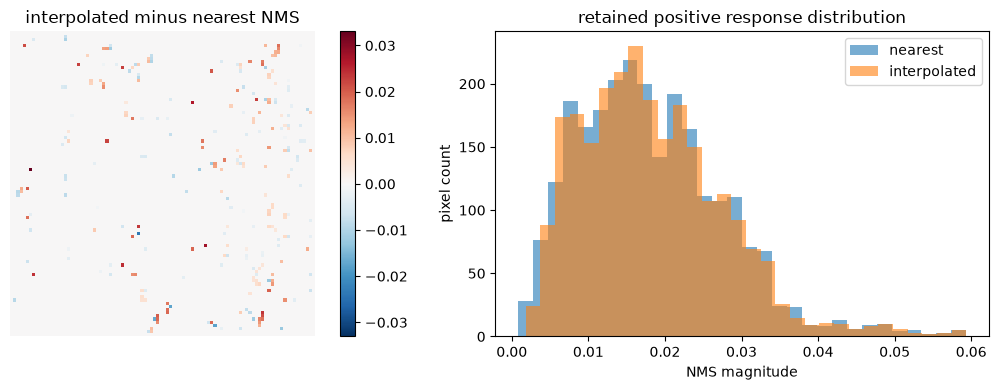

In [7]:
difference = edge["nms"] - nearest
difference_limit = max(float(np.abs(difference).max()), np.finfo(np.float32).eps)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
im = axes[0].imshow(
    difference, cmap="RdBu_r", vmin=-difference_limit, vmax=difference_limit
)
axes[0].set_title("interpolated minus nearest NMS")
axes[0].axis("off")
fig.colorbar(im, ax=axes[0])
axes[1].hist(nearest[nearest > 0], bins=30, alpha=0.6, label="nearest")
axes[1].hist(edge["nms"][edge["nms"] > 0], bins=30, alpha=0.6, label="interpolated")
axes[1].set_title("retained positive response distribution")
axes[1].set_xlabel("NMS magnitude")
axes[1].set_ylabel("pixel count")
axes[1].legend()
fig.tight_layout()
plt.show()

## 6. Assemble and audit the shared local descriptor
Colour, Gabor energy, gradient energy, and edge densities must all have the same height and width.

input: (96, 96, 3) features: (96, 96, 21) named channels: 21 finite: True


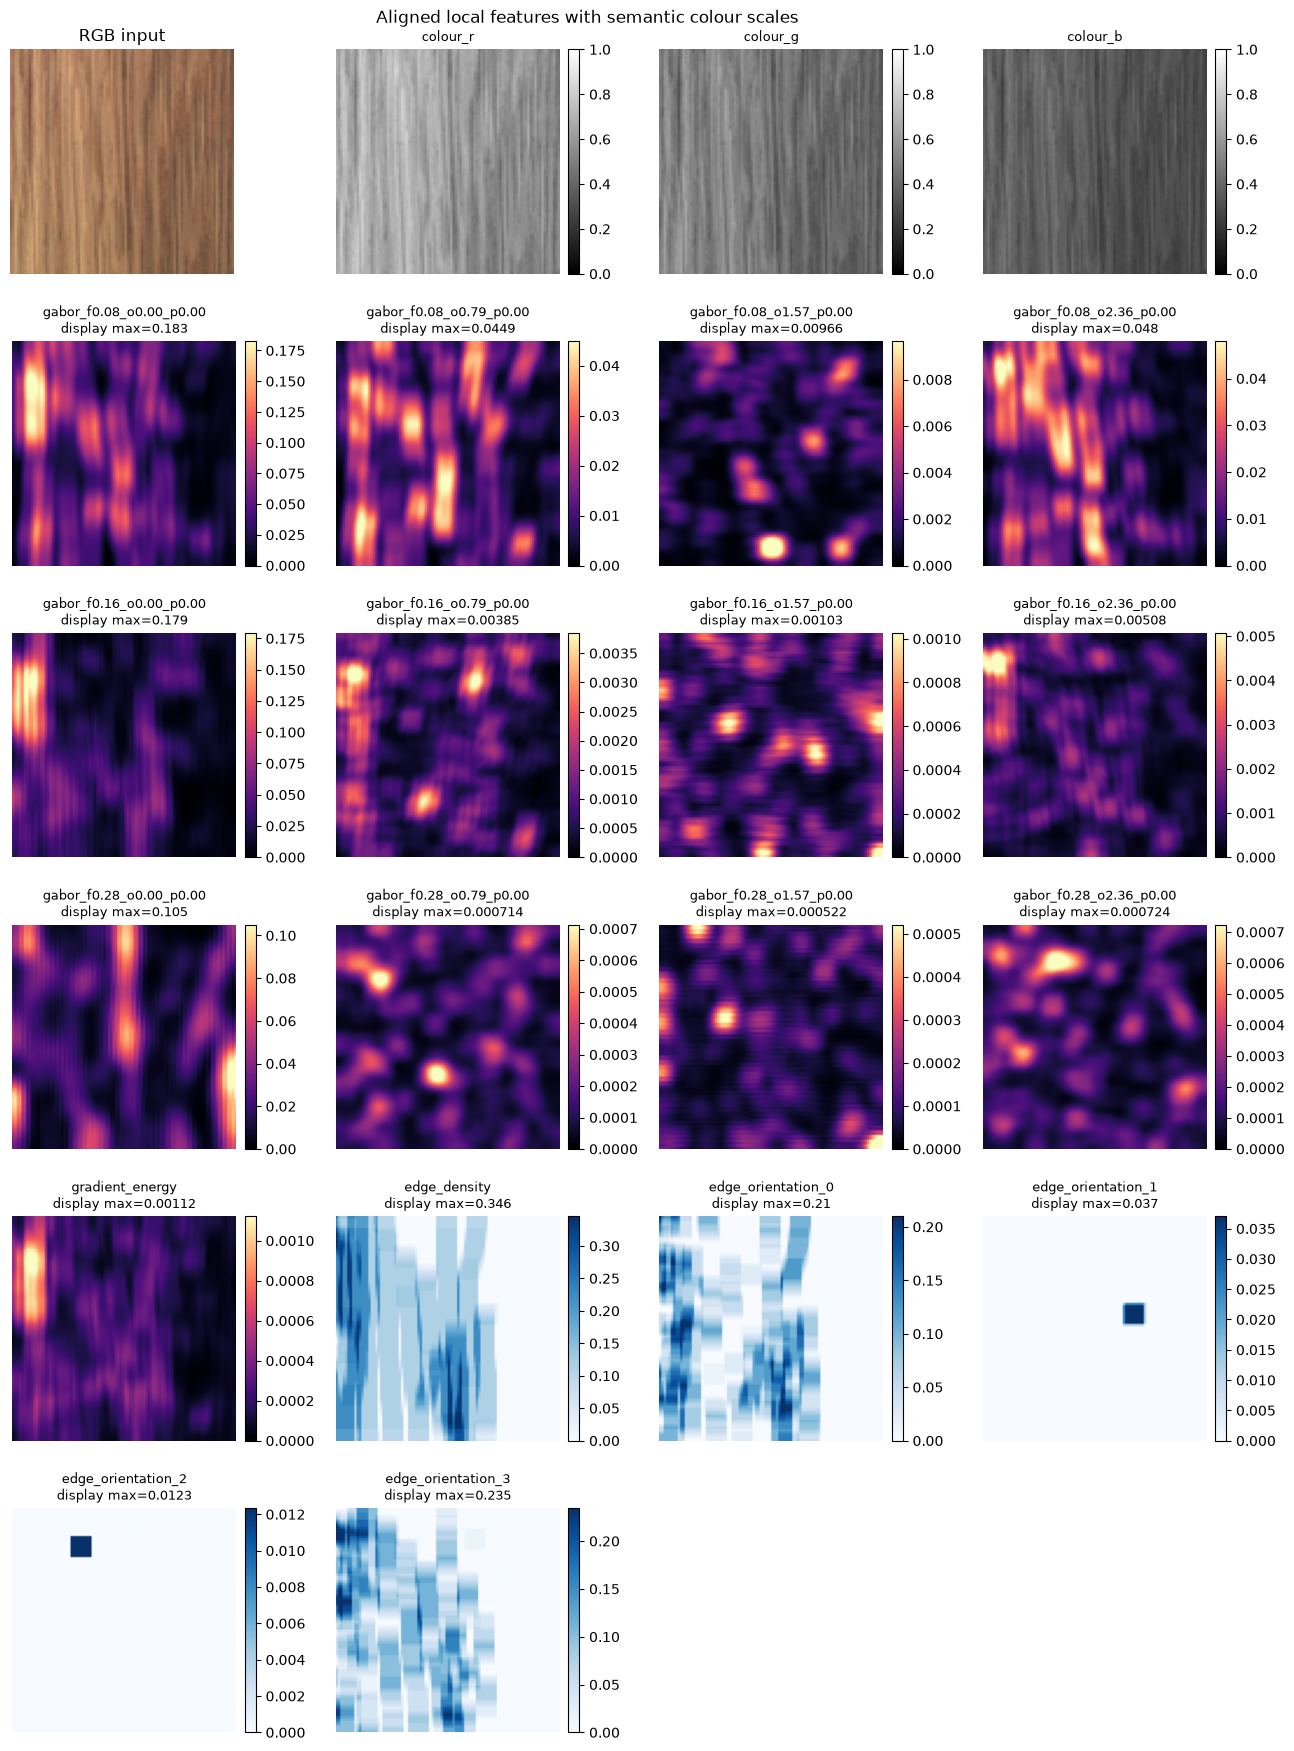

In [8]:
features, names = extract_local_features(image, config)
print(
    "input:",
    image.shape,
    "features:",
    features.shape,
    "named channels:",
    len(names),
    "finite:",
    np.isfinite(features).all(),
)

# Render each channel according to its meaning. Colour, Gabor energy,
# gradient energy, and edge density are non-negative. Robust per-channel
# limits expose weak orientation maps; each title reports that limit.
count = len(names)
columns = 4
rows = int(np.ceil((count + 1) / columns))
fig, axes = plt.subplots(rows, columns, figsize=(4 * columns, 3.3 * rows))
axes = np.asarray(axes).ravel()
axes[0].imshow(image)
axes[0].set_title("RGB input")
for index, name in enumerate(names):
    channel = features[..., index]
    if name.startswith("colour_"):
        cmap, vmin, vmax = "gray", 0.0, 1.0
    elif name.startswith("edge_"):
        cmap, vmin = "Blues", 0.0
        vmax = max(float(np.percentile(channel, 99.5)), np.finfo(np.float32).eps)
    else:
        cmap, vmin = "magma", 0.0
        vmax = max(float(np.percentile(channel, 99.5)), np.finfo(np.float32).eps)
    artist = axes[index + 1].imshow(channel, cmap=cmap, vmin=vmin, vmax=vmax)
    scale_note = f"\ndisplay max={vmax:.3g}" if not name.startswith("colour_") else ""
    axes[index + 1].set_title(name + scale_note, fontsize=9)
    fig.colorbar(artist, ax=axes[index + 1], fraction=0.046, pad=0.03)
for ax in axes:
    ax.axis("off")
for ax in axes[count + 1:]:
    ax.set_visible(False)
fig.suptitle("Aligned local features with semantic colour scales")
fig.subplots_adjust(top=0.96, wspace=0.20, hspace=0.30)
plt.show()

edge_indices = [i for i, name in enumerate(names) if name.startswith("edge_")]
gradient_indices = [i for i, name in enumerate(names) if name == "gradient_energy"]
assert np.all(features[..., edge_indices] >= 0) and np.all(features[..., edge_indices] <= 1)
assert np.all(features[..., gradient_indices] >= 0)

### Compare feature-channel scales
Large scale differences motivate the StandardScaler inside the scikit-learn classification pipelines.

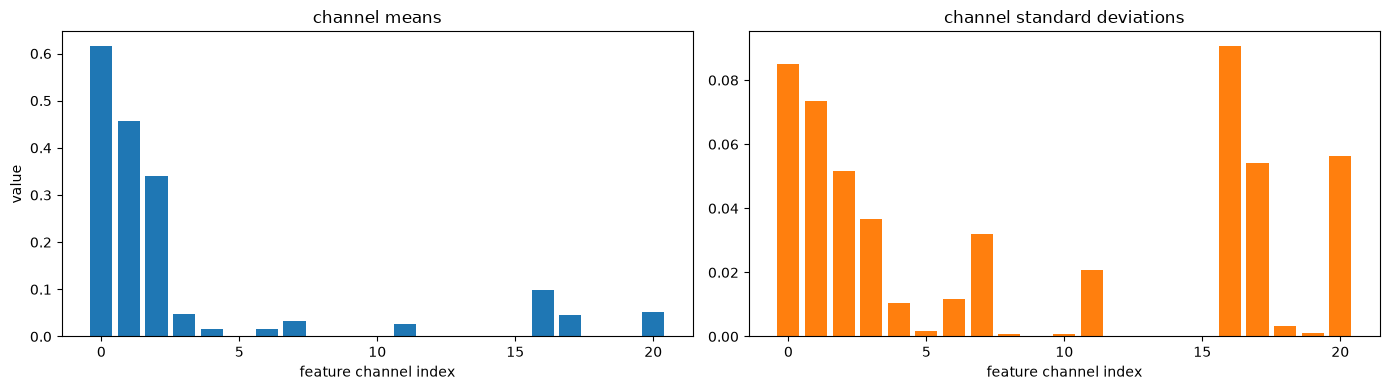

In [9]:
channel_mean = features.mean((0, 1))
channel_std = features.std((0, 1))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(len(names)), channel_mean)
axes[0].set_title("channel means")
axes[0].set_ylabel("value")
axes[1].bar(range(len(names)), channel_std, color="tab:orange")
axes[1].set_title("channel standard deviations")
for ax in axes:
    ax.set_xlabel("feature channel index")
fig.tight_layout()

## Reflection prompts
1. Which orientations respond most strongly?  
2. Where does interpolated NMS differ from the baseline?  
3. Which channels should detect a scratch, and which should detect a diffuse stain?